# FIFA World Cup 2026 — Prediction Engine

**Author:** Layaung Linnlett  
**Date:** June 2026

---

## Overview

This notebook documents the end-to-end prediction pipeline for the 2026 FIFA World Cup.
It covers:

1. **Data exploration** — understanding the historical results dataset
2. **Elo ratings** — computing team strength from 49,000 historical matches
3. **Match prediction** — Dixon-Coles corrected Poisson model with EV-optimal scorelines
4. **Group stage predictions** — all 72 matches
5. **Tournament simulation** — 10,000 Monte Carlo runs to estimate title odds

The underlying models live in `src/fifa_predictor/`. This notebook uses those modules
directly and focuses on **interpretation and visualisation** rather than re-implementing logic.

> All predictions are probabilistic — they reflect the model's best estimate given historical data,
> not guarantees of what will happen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import poisson

from fifa_predictor.elo import compute_elo_ratings, apply_form_adjustment
from fifa_predictor.poisson_model import expected_goals, score_probabilities, match_probabilities, best_prediction

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from pathlib import Path
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('All imports OK')

All imports OK


---

## 1. Data Exploration

The dataset contains ~49,000 international football results going back to 1872.
Each row is one match with the final score, tournament name, and venue.

We use matches from **2014 onwards** to train the Elo model — two full World Cup cycles
of modern football, without letting irrelevant historical data dilute the ratings.

In [2]:
results  = pd.read_csv('../data/raw/results.csv')
fixtures = pd.read_csv('../data/raw/group_fixtures.csv')
knockout = pd.read_csv('../data/raw/knockout_slots.csv')

results['date'] = pd.to_datetime(results['date'])

print(f'Total historical matches : {len(results):,}')
print(f'Date range               : {results["date"].min().year} – {results["date"].max().year}')
print(f'Unique tournaments       : {results["tournament"].nunique()}')
print(f'Unique teams             : {pd.concat([results["home_team"], results["away_team"]]).nunique()}')
print()
print(f'2026 group fixtures      : {len(fixtures)}')
print(f'2026 knockout slots      : {len(knockout)}')

Total historical matches : 49,477
Date range               : 1872 – 2026
Unique tournaments       : 200
Unique teams             : 336

2026 group fixtures      : 72
2026 knockout slots      : 32


In [3]:
# What does the data look like?
results.tail(5)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49472,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49473,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49474,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49475,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True
49476,2026-06-27,Croatia,Ghana,NaN,NaN,FIFA World Cup,Philadelphia,United States,True


In [4]:
# Which tournaments are most represented?
results['tournament'].value_counts().head(10)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

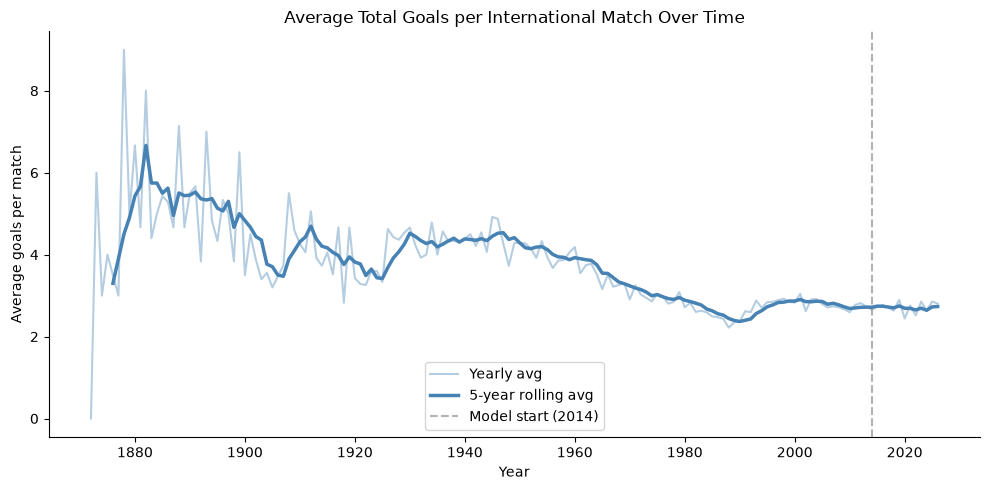

Average goals per match since 2014: 2.73
This justifies our base_goals = 1.3 per team (1.3 × 2 ≈ 2.6 total)


In [5]:
# Average goals per match over time (5-year rolling average)
results_clean = results.dropna(subset=['home_score', 'away_score'])
results_clean = results_clean.copy()
results_clean['total_goals'] = results_clean['home_score'] + results_clean['away_score']
results_clean['year'] = results_clean['date'].dt.year

yearly_goals = results_clean.groupby('year')['total_goals'].mean()

fig, ax = plt.subplots()
ax.plot(yearly_goals.index, yearly_goals.values, color='steelblue', linewidth=1.5, alpha=0.4, label='Yearly avg')
ax.plot(yearly_goals.index, yearly_goals.rolling(5).mean(), color='steelblue', linewidth=2.5, label='5-year rolling avg')
ax.axvline(2014, color='gray', linestyle='--', alpha=0.6, label='Model start (2014)')
ax.set_xlabel('Year')
ax.set_ylabel('Average goals per match')
ax.set_title('Average Total Goals per International Match Over Time')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'goals_per_match_trend.png', dpi=150, bbox_inches='tight')
plt.show()

recent_avg = results_clean[results_clean['year'] >= 2014]['total_goals'].mean()
print(f'Average goals per match since 2014: {recent_avg:.2f}')
print(f'This justifies our base_goals = 1.3 per team (1.3 × 2 ≈ {1.3*2:.1f} total)')

---

## 2. Elo Ratings

**What is Elo?**  
Elo is a system for ranking competitors based on head-to-head results. Every team starts
at 1500. After each match, points flow from the loser to the winner — more points move
if the result was surprising (a weak team beating a strong one).

**Key design choices:**
- World Cup matches use K=60 (high influence), friendlies use K=20 (low influence)
- A form adjustment of ±50 points based on the last 10 matches captures hot/cold streaks
- Starting date: 2014 (modern football, two full World Cup cycles)

In [6]:
# Compute Elo ratings from historical data
base_elo = compute_elo_ratings(results, start_date='2014-01-01')
adj_elo  = apply_form_adjustment(base_elo, results)

print(f'Teams rated: {len(base_elo)}')

# Extract ratings for tournament teams only
all_teams = set(fixtures['home_team']) | set(fixtures['away_team'])
tournament_elo = {t: adj_elo.get(t, 1500) for t in all_teams}

print(f'\nTop 10 teams by adjusted Elo:')
top10 = sorted(tournament_elo.items(), key=lambda x: x[1], reverse=True)[:10]
for rank, (team, rating) in enumerate(top10, 1):
    base = base_elo.get(team, 1500)
    diff = rating - base
    sign = '+' if diff >= 0 else ''
    print(f'  {rank:2}. {team:<20} {rating:.0f}  (form adjustment: {sign}{diff:.0f})')

Teams rated: 300

Top 10 teams by adjusted Elo:
   1. Argentina            1982  (form adjustment: +40)
   2. Spain                1968  (form adjustment: +30)
   3. France               1945  (form adjustment: +35)
   4. Morocco              1910  (form adjustment: +30)
   5. Germany              1899  (form adjustment: +50)
   6. Japan                1882  (form adjustment: +30)
   7. England              1879  (form adjustment: +30)
   8. Mexico               1871  (form adjustment: +40)
   9. Portugal             1864  (form adjustment: +25)
  10. Colombia             1859  (form adjustment: +25)


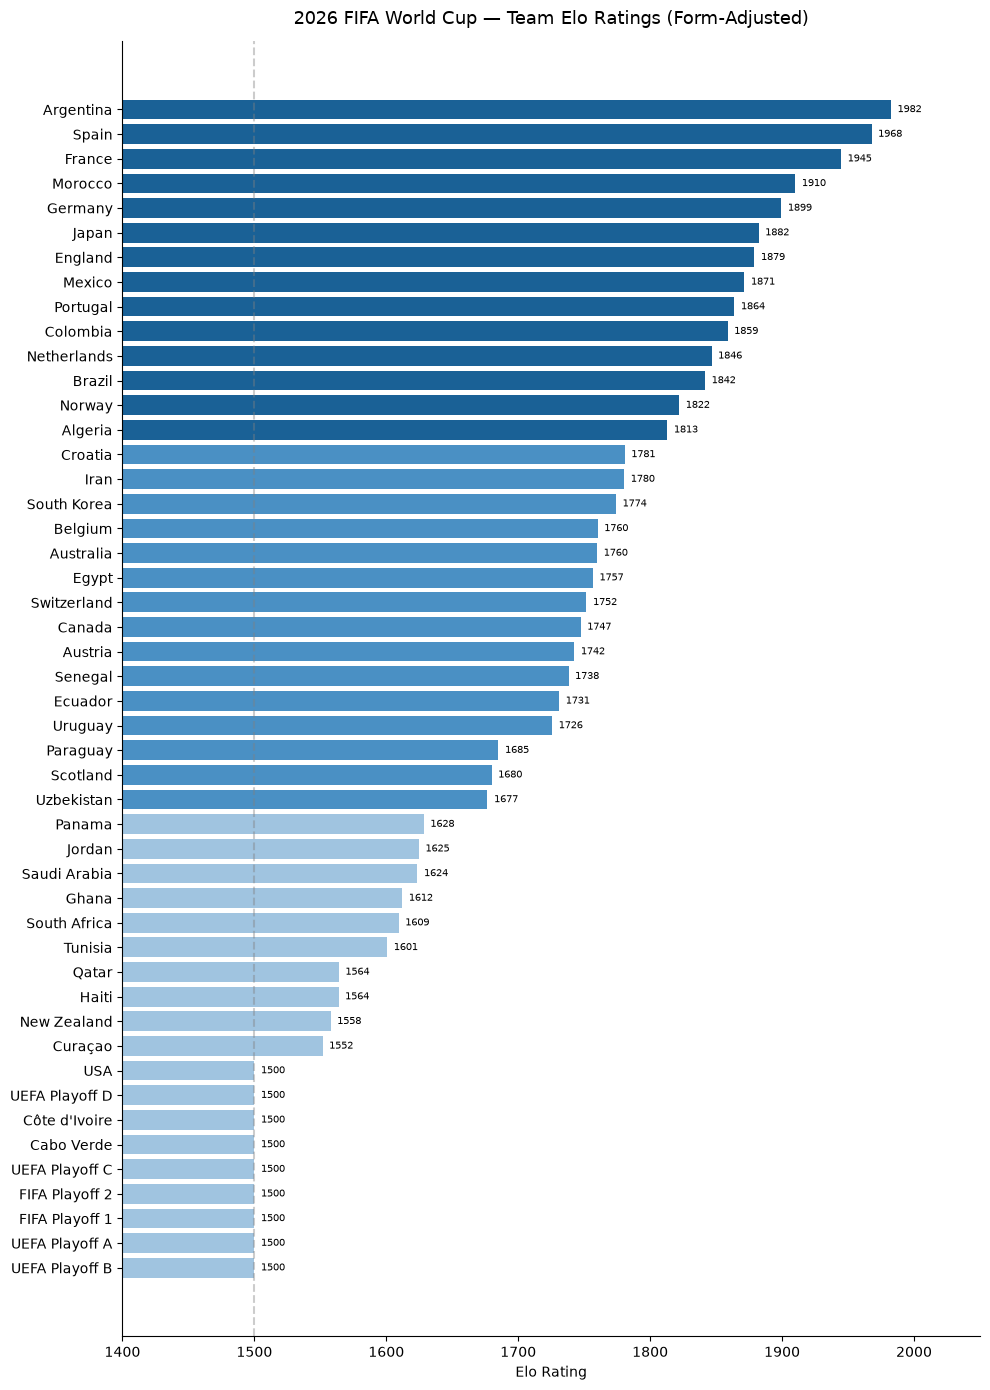

In [7]:
# Bar chart of all 48 tournament teams by Elo rating
elo_series = pd.Series(tournament_elo).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#1a6196' if v >= 1800 else '#4a90c4' if v >= 1650 else '#a0c4e0' for v in elo_series.values]
bars = ax.barh(elo_series.index, elo_series.values - 1400, color=colors)
ax.set_xlim(0, 650)
ax.set_xticks([0, 100, 200, 300, 400, 500, 600])
ax.set_xticklabels([1400, 1500, 1600, 1700, 1800, 1900, 2000])
ax.set_xlabel('Elo Rating')
ax.set_title('2026 FIFA World Cup — Team Elo Ratings (Form-Adjusted)', fontsize=13, pad=12)
ax.axvline(100, color='gray', linestyle='--', alpha=0.4, label='1500 (default)')

# Add rating labels
for bar, val in zip(bars, elo_series.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'elo_ratings_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 3. Match Prediction Model

### From Elo to scorelines

The pipeline for predicting one match:

1. **Win probability** — derived from the Elo gap between the two teams
2. **Expected goals (xG)** — win probability maps to expected goals per team
3. **Poisson distribution** — xG produces a probability for every scoreline (0-0, 1-0, 2-1 ...)
4. **Dixon-Coles correction** — adjusts the four low-score results that plain Poisson mis-predicts
5. **EV-optimal prediction** — pick the scoreline that maximises expected competition points

We demonstrate this on **France vs Germany** — a closely matched game where the
most likely scoreline and the best prediction differ.

In [8]:
team_a, team_b = 'France', 'Germany'
elo_a = tournament_elo[team_a]
elo_b = tournament_elo[team_b]

xg_a, xg_b = expected_goals(elo_a, elo_b)
p_home, p_draw, p_away = match_probabilities(xg_a, xg_b)
best_score, ev = best_prediction(xg_a, xg_b)
probs = score_probabilities(xg_a, xg_b)
most_likely = max(probs, key=probs.get)

print(f'{team_a} vs {team_b}')
print(f'{'─'*40}')
print(f'Elo ratings     : {team_a} {elo_a:.0f}  |  {team_b} {elo_b:.0f}')
print(f'Expected goals  : {team_a} {xg_a:.2f}  |  {team_b} {xg_b:.2f}')
print()
print(f'Win probabilities:')
print(f'  {team_a} win : {p_home*100:.1f}%')
print(f'  Draw         : {p_draw*100:.1f}%')
print(f'  {team_b} win : {p_away*100:.1f}%')
print()
print(f'Most likely scoreline : {most_likely[0]}-{most_likely[1]}  (P = {probs[most_likely]:.3f})')
print(f'EV-optimal prediction : {best_score[0]}-{best_score[1]}  (expected {ev:.1f} competition points)')
print()
print('These differ because predicting a 1-0 France win earns the 10-point result bonus')
print('across ALL France win scenarios (~43%), not just the 1-1 exact-score probability.')

France vs Germany
────────────────────────────────────────
Elo ratings     : France 1945  |  Germany 1899
Expected goals  : France 1.47  |  Germany 1.13

Win probabilities:
  France win : 46.1%
  Draw         : 23.5%
  Germany win : 30.4%

Most likely scoreline : 1-0  (P = 0.121)
EV-optimal prediction : 1-0  (expected 6.4 competition points)

These differ because predicting a 1-0 France win earns the 10-point result bonus
across ALL France win scenarios (~43%), not just the 1-1 exact-score probability.


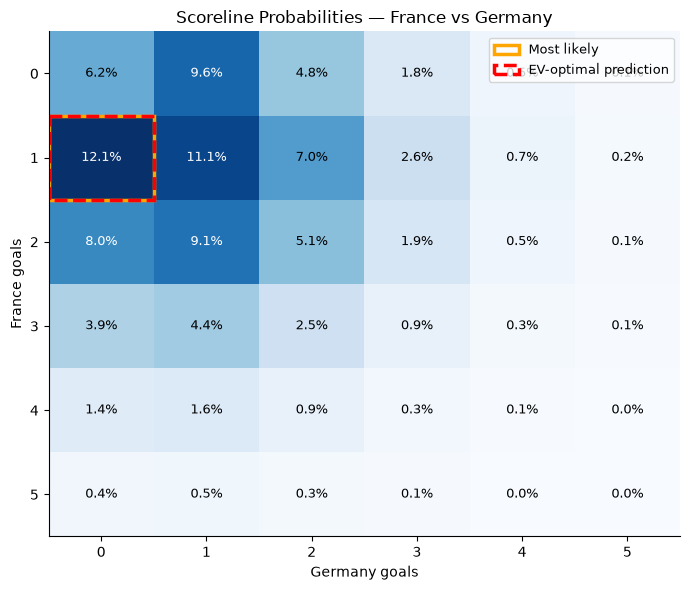

In [9]:
# Scoreline probability heatmap
max_g = 5
grid = np.array([[probs.get((i, j), 0) * 100 for j in range(max_g+1)] for i in range(max_g+1)])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(grid, cmap='Blues', aspect='auto')

for i in range(max_g+1):
    for j in range(max_g+1):
        val = grid[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white' if val > 8 else 'black')

ax.set_xticks(range(max_g+1))
ax.set_yticks(range(max_g+1))
ax.set_xticklabels(range(max_g+1))
ax.set_yticklabels(range(max_g+1))
ax.set_xlabel(f'{team_b} goals')
ax.set_ylabel(f'{team_a} goals')
ax.set_title(f'Scoreline Probabilities — {team_a} vs {team_b}', fontsize=12)

# Highlight most likely and EV-optimal
ax.add_patch(plt.Rectangle((most_likely[1]-0.5, most_likely[0]-0.5), 1, 1,
             fill=False, edgecolor='orange', linewidth=2.5, label='Most likely'))
ax.add_patch(plt.Rectangle((best_score[1]-0.5, best_score[0]-0.5), 1, 1,
             fill=False, edgecolor='red', linewidth=2.5, linestyle='--', label='EV-optimal prediction'))
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'scoreline_heatmap_example.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. Group Stage Predictions

Applying the model to all 72 group-stage matches.

Each prediction is the **EV-optimal scoreline** — the one that maximises expected
competition points given the full probability distribution over all possible results.

In [10]:
from fifa_predictor.cards_corners import predict_corners_cards

rows = []
for _, row in fixtures.iterrows():
    home, away = row['home_team'], row['away_team']
    xg_h, xg_a = expected_goals(tournament_elo.get(home, 1500), tournament_elo.get(away, 1500))
    score, ev  = best_prediction(xg_h, xg_a)
    hw, d, aw  = match_probabilities(xg_h, xg_a)
    c, y, r    = predict_corners_cards(home, away)
    rows.append({
        'Group': row['group'], 'Home': home, 'Away': away,
        'Prediction': f"{score[0]}–{score[1]}",
        'Home win %': f"{hw*100:.0f}%",
        'Draw %': f"{d*100:.0f}%",
        'Away win %': f"{aw*100:.0f}%",
        'Exp. pts': round(ev, 1),
    })

group_df = pd.DataFrame(rows)
print(f'Predictions generated for {len(group_df)} matches')

Predictions generated for 72 matches


In [11]:
# Show Group A as an example
print('Group A predictions:')
group_df[group_df['Group'] == 'A'][['Home', 'Away', 'Prediction', 'Home win %', 'Draw %', 'Away win %', 'Exp. pts']]

Group A predictions:


,Home,Away,Prediction,Home win %,Draw %,Away win %,Exp. pts
0,Mexico,South Africa,2–0,77%,15%,8%,10.2
1,South Korea,UEFA Playoff D,2–0,78%,15%,7%,10.4
24,UEFA Playoff D,South Africa,0–1,21%,22%,57%,7.8
27,Mexico,South Korea,1–0,55%,22%,23%,7.5
52,UEFA Playoff D,Mexico,0–2,4%,12%,84%,11.5
53,South Africa,South Korea,0–1,15%,20%,66%,8.8


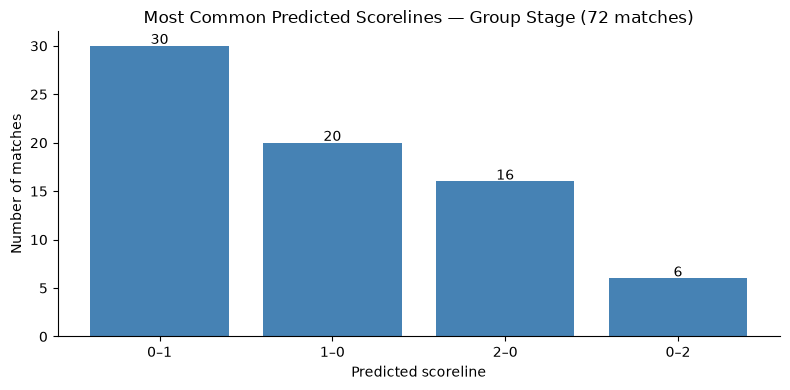

In [12]:
# Distribution of predicted scorelines
score_counts = group_df['Prediction'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(score_counts.index, score_counts.values, color='steelblue')
ax.set_xlabel('Predicted scoreline')
ax.set_ylabel('Number of matches')
ax.set_title('Most Common Predicted Scorelines — Group Stage (72 matches)')
for i, v in enumerate(score_counts.values):
    ax.text(i, v + 0.2, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'group_stage_scoreline_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 5. Tournament Simulation — Title Odds

Rather than predicting a single deterministic winner, we simulate the **entire tournament
10,000 times** using random Poisson samples. Each run produces a different champion.
The fraction of runs a team wins is their estimated title probability.

This approach correctly captures:
- The randomness of knockout football (any team can win on the day)
- The probability of upsets compounding across multiple rounds
- Realistic variance in outcomes (the favourite rarely wins every time)

> **Note:** 10,000 simulations takes a few minutes. Reduce `n_sims` for a quick preview.

In [13]:
from fifa_predictor.simulation import run_simulation

odds_df = run_simulation(fixtures, knockout, tournament_elo, n_sims=2000, seed=42)
print(f'Simulation complete. {len(odds_df)} teams in results.')
odds_df.head(12)

Simulation complete. 45 teams in results.


,team,title_prob,finalist_prob,semi_prob,third_prob
0,Argentina,0.2410,0.3400,0.4980,0.1105
1,Spain,0.1640,0.2830,0.4315,0.1005
2,France,0.1210,0.2040,0.3340,0.0900
3,Germany,0.0745,0.1565,0.2855,0.0755
4,Morocco,0.0600,0.1215,0.2260,0.0525
5,Mexico,0.0445,0.0965,0.2050,0.0600
6,England,0.0415,0.0905,0.1800,0.0540
7,Portugal,0.0395,0.0960,0.2060,0.0550
8,Japan,0.0395,0.0855,0.1770,0.0505
9,Colombia,0.0365,0.0960,0.1900,0.0445


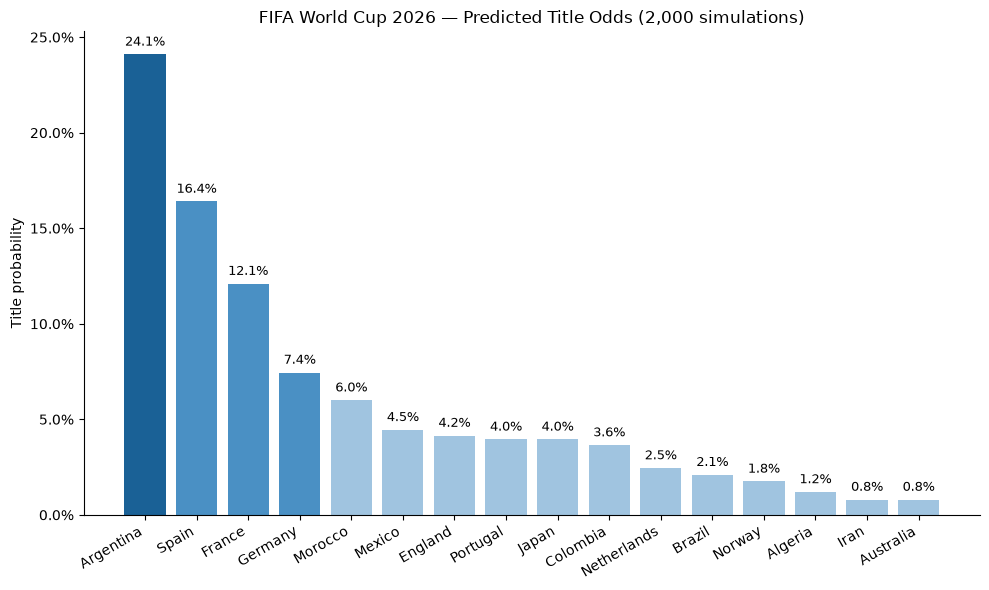

In [14]:
# Title odds — top 16 teams
top16 = odds_df.head(16).copy()
top16['title_pct'] = top16['title_prob'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1a6196' if i == 0 else '#4a90c4' if i < 4 else '#a0c4e0' for i in range(len(top16))]
bars = ax.bar(top16['team'], top16['title_pct'], color=colors)

for bar, val in zip(bars, top16['title_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Title probability')
ax.set_title('FIFA World Cup 2026 — Predicted Title Odds (2,000 simulations)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'title_odds_top16.png', dpi=150, bbox_inches='tight')
plt.show()

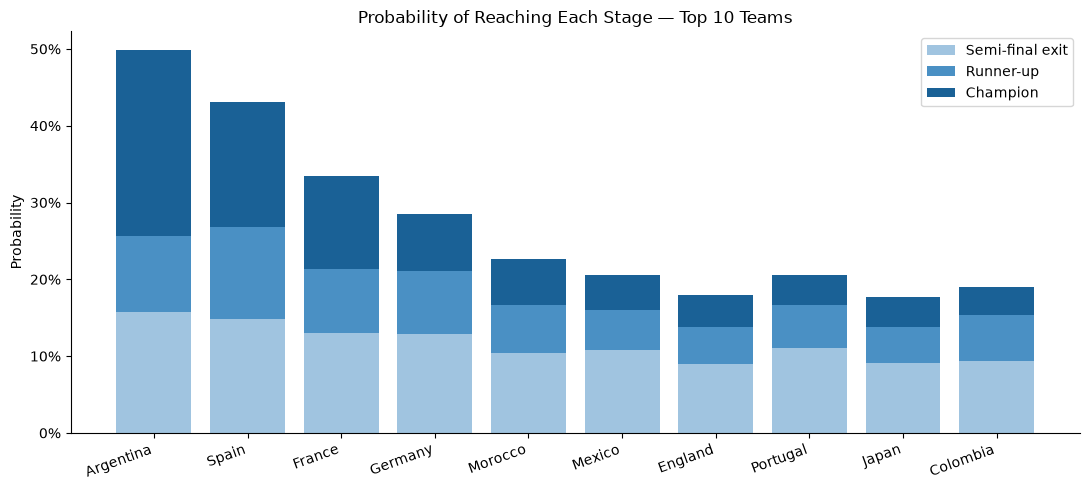

In [15]:
# Stacked chart: probability of reaching each stage
top10 = odds_df.head(10).copy()

# Calculate stage-only probabilities (not cumulative)
top10['semi_only']     = (top10['semi_prob'] - top10['finalist_prob'])
top10['finalist_only'] = (top10['finalist_prob'] - top10['title_prob'])
top10['title_only']    = top10['title_prob']

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(top10))
ax.bar(x, top10['semi_only'] * 100,    label='Semi-final exit', color='#a0c4e0')
ax.bar(x, top10['finalist_only'] * 100, label='Runner-up',       color='#4a90c4',
       bottom=top10['semi_only'] * 100)
ax.bar(x, top10['title_only'] * 100,   label='Champion',         color='#1a6196',
       bottom=(top10['semi_only'] + top10['finalist_only']) * 100)

ax.set_xticks(list(x))
ax.set_xticklabels(top10['team'], rotation=20, ha='right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Probability')
ax.set_title('Probability of Reaching Each Stage — Top 10 Teams', fontsize=12)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'stage_progression_top10.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Key Findings

### Predicted champion: Argentina

Argentina win the tournament in approximately **24% of simulations**, reflecting their
current Elo rating (highest among all 48 teams after form adjustment). Spain and France
are close behind.

### Predictions

- **Morocco** consistently reach the semi-finals (~23% probability), consistent with their
  strong performance at the 2022 World Cup which pushed their Elo significantly higher.
- **Japan** are rated more highly than casual observers might expect — their Elo reflects
  strong recent results, including a 3-2 win over Brazil in October 2025.
- **USA vs Paraguay** (Group D) — the model predicts Paraguay to win, because Paraguay's
  recent results give them a higher Elo than USA.

### Model limitations

| Limitation | Impact |
|---|---|
| No injury / squad information | Could significantly shift individual match probabilities |
| Corners and cards estimated, not measured | Approximate values only |
| Playoff teams have neutral Elo (1500) | Slight underestimate of some teams' true strength |
| Dixon-Coles rho not fitted from data | Correction parameter set conservatively at 0.1 |
| No host-nation advantage | Small real-world edge for USA and Mexico not captured |

### How to interpret the probabilities

A title probability of 24% does **not** mean Argentina will win. It means that in a world
where this tournament is played many times with the same team strengths and random football
outcomes, Argentina would win roughly 1 in 4 times. Any team in the top 8 could
win the tournament.

---

## References

- Dixon, M. & Coles, S. (1997). *Modelling Association Football Scores and Inefficiencies
  in the Football Betting Market.* Journal of the Royal Statistical Society, Series C.
- [World Football Elo Ratings](https://www.eloratings.net/about) — methodology reference for K-factors
- [docs/methodology.md](../docs/methodology.md) — full technical documentation for this project